In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from pathlib import Path

BASE    = Path(r"C:\Users\pacor\Documents\Notebooks\Python\Inpat Expat\inpat-expat\corto-muso")
DB_PATH = BASE / "tm_football.db"
DATA    = BASE / "data"


In [3]:
def corto_muso_summary(managers, data):
    wins = data[data["result"] == "W"].copy()

    wins["is_one_nil"] = (
        (wins["goals_for"] == 1) & (wins["goals_against"] == 0)
    )
    wins["is_min_response"] = (
        (wins["goals_against"] > 0) & (wins["goal_diff"] == 1)
    )

    assert (wins["is_one_nil"] & wins["is_min_response"]).sum() == 0, "overlap detected"

    wins["is_corto_muso_win"] = wins["is_one_nil"] | wins["is_min_response"]

    total_matches = (
        data[data["manager"].isin(managers)]
        .groupby("manager")["result"]
        .count()
        .rename("total_matches")
    )

    summary = (
        wins[wins["manager"].isin(managers)]
        .groupby("manager")
        .agg(
            total_wins   = ("result", "count"),
            one_nil      = ("is_one_nil", "sum"),
            min_response = ("is_min_response", "sum"),
            corto_muso   = ("is_corto_muso_win", "sum"),
        )
        .loc[managers]
    )

    summary = summary.join(total_matches)
    summary["win_%"]        = (summary["total_wins"]  / summary["total_matches"] * 100).round(1)
    summary["1-0_%"]        = (summary["one_nil"]      / summary["total_wins"] * 100).round(1)
    summary["min_resp_%"]   = (summary["min_response"] / summary["total_wins"] * 100).round(1)
    summary["corto_muso_%"] = (summary["corto_muso"]   / summary["total_wins"] * 100).round(1)

    return summary[["total_matches", 
                    "total_wins", 
                    "one_nil",
                    "min_response", 
                    "corto_muso", 
                    "win_%", 
                    "1-0_%", 
                    "min_resp_%",
                    "corto_muso_%"]]



In [4]:
def get_counts(manager_name, data):
    sub   = data[data["manager"] == manager_name]
    w     = sub[sub["result"] == "W"].copy()
    w["is_one_nil"]      = (w["goals_for"] == 1) & (w["goals_against"] == 0)
    w["is_min_response"] = (w["goals_against"] > 0) & (w["goal_diff"] == 1)
    w_opp = w[w["goals_against"] > 0]
    return {
        "matches"    : len(sub),
        "wins"       : len(w),
        "one_nil"    : int(w["is_one_nil"].sum()),
        "min_resp"   : int(w["is_min_response"].sum()),
        "opp_scored" : len(w_opp),
    }


In [45]:
def plot_corto_muso_signals(data, managers, reference="Massimiliano Allegri", order=3):

    rows = []
    for manager in managers:
        sub = data[data["manager"] == manager]
        w = sub[sub["result"] == "W"].copy()
        w["is_one_nil"]      = (w["goals_for"] == 1) & (w["goals_against"] == 0)
        w["is_min_response"] = (w["goals_against"] > 0) & (w["goal_diff"] == 1)
        w["is_corto_muso"]   = w["is_one_nil"] | w["is_min_response"]
        rows.append({
            "manager"     : manager,
            "matches"     : len(sub),
            "win_n"       : len(w),
            "one_nil_n"   : int(w["is_one_nil"].sum()),
            "min_resp_n"  : int(w["is_min_response"].sum()),
            "corto_muso_n": int(w["is_corto_muso"].sum()),
            "opp_scored_n": int((w["goals_against"] > 0).sum()),
        })
    ci_df = pd.DataFrame(rows).set_index("manager")

    ref   = ci_df.loc[reference]
    peers = [m for m in managers if m != reference]

    panel_specs = [
        ("win_%",        "win_n",          "matches",      "Win %",                         "% of all matches"),
        ("1-0_%",        "one_nil_n",       "win_n",        "1-0 wins % of wins",            "% of wins"),
        ("min_resp_%",   "min_resp_n",      "opp_scored_n", "Min-response %\n(opp. scored)", "% of wins where opp. scored"),
        ("corto_muso_%", "corto_muso_n",    "win_n",        "Corto muso % of wins",          "% of wins"),
    ]

    pval_bh = {}
    for metric, count_col, denom_col, _, _ in panel_specs:
        raw = []
        for peer in peers:
            p = ci_df.loc[peer]
            _, pv = proportions_ztest(
                [ref[count_col], p[count_col]],
                [ref[denom_col], p[denom_col]]
            )
            raw.append(pv)
        _, corrected, _, _ = multipletests(raw, method="fdr_bh")
        pval_bh[metric] = dict(zip(peers, corrected))

    # sort by the chosen panel
    sort_metric, sort_count, sort_denom, _, _ = panel_specs[order]
    sort_order = (
        ci_df[sort_count] / ci_df[sort_denom] * 100
    ).sort_values(ascending=True).index.tolist()

    blues = cm.Blues

    fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharey=True)

    for ax, (metric, count_col, denom_col, title, xlabel) in zip(axes, panel_specs):
        for manager in sort_order:
            row   = ci_df.loc[manager]
            n     = int(row[count_col])
            denom = int(row[denom_col])
            lo, hi = proportion_confint(n, denom, alpha=0.05, method="wilson")
            pct   = n / denom * 100

            if manager == reference:
                color = "tomato"
            else:
                pv        = pval_bh[metric].get(manager, 1.0)
                intensity = 0.25 + 0.65 * float(pv)
                color     = blues(intensity)

            ax.plot(pct, manager, "o", color=color, markersize=7, zorder=3)
            ax.plot([lo*100, hi*100], [manager, manager], color=color, linewidth=2, zorder=2)

        ax.axvline(
            ci_df.loc[reference, count_col] / ci_df.loc[reference, denom_col] * 100,
            color="tomato", linestyle="--", linewidth=1, alpha=0.5
        )
        ax.set_title(title, fontsize=9)
        ax.set_xlabel(xlabel, fontsize=8)
        ax.grid(axis="x", color="lightgrey", linewidth=0.5, zorder=0)

    fig.suptitle(
        "Corto muso signals — Big 5 domestic leagues\n"
        "(dot = estimate, bar = 95% Wilson CI; darker blue = more significant vs reference)",
        fontsize=10
    )
    plt.tight_layout()
    plt.show()


# Al 100% e' quasi: Allegri e i risultati di corto muso

> [*Non c'e' bisogno che vinci di 100, basta mettere il muso d'avanti*](https://www.youtube.com/watch?v=xbcC8oXZzvA) - Massimiliano Allegri sul corto muso

Spesso ho l'impressione che chi segua il calcio, anche tra gli addetti ai lavori, abbia un atteggiamento schizofrenico nei confronti dei numeri e della matematica. Il calcio e' un gioco che, nel momento in cui si trasforma in sport, definisce delle misure e quindi, intrinsecamente, dei parametri per confrontare queste misure. Si puo' benissimo *giocare* a calcio, come fanno i bambini, e il tuo scopo e' divertirti calciando una palla e cercando di controllarla e direzionarla mentre rimbalza. Personalmente, e' come se ci fosse una gioia interiore nel solo cercare di padroneggiare la palla, scartare i tuoi avversari, correre e, al tempo stesso, direzionare un oggetto che, d'avanti a te, rimbalza e si sposta in maniera spesso imprevedibile. Tutto questo, immaginandoti nello stadio Azteca di Citta' del Messico. E questo e' il gioco. Lo sport inizia, ad esempio, quando iniziamo a contare i goal che facciamo o che subiamo e, quindi, a misurare una prestazione. Da li in poi, si possono definire altre misure e quindi numeri che le rappresentano. 

Ci piaccia o no, e [capisco che non possa piacere](https://www.tuttonapoli.net/radio-tutto-napoli/conte-batte-quasi-sempre-allegri-cagni-ma-statistiche-non-dicono-nulla-641402), ma una volta che si mettono in mezzo i numeri e le misure, e' difficile non farci entrare concetti come la probabilita' e la statistica. Parlando di calcio, non e' obbligatorio parlare di numeri e statistica. Si possono descrivere le partite anche in termini coinvolgimento emotivo, usando parametri soggettivi come la bellezza, l'ansia, la felicita' e il terrore. 

Se si vuole, pero', parlare di calcio attraverso i numeri, e quindi usando misure, e' bene essere chiari e onesti so come trattarli e comunicarli. Inoltre, se si vogliono usare i numeri per dimostrare una tesi, allora bisogna dichiarare a che gioco si vuol giocare dal principio per evitare fraintendimenti. Un "approccio scientifico" all'interpretazione dei risultati nel calcio e' possibile, secondo me, se si sa di cosa si parla e si comunicano chiaramente gli obiettivi e i limiti. Nessuno ci obbliga a farlo, ma se lo facciamo cerchiamo di farlo con cognizione di causa e chiarendo subito cosa si vuol ottenere. Evitare equivoci ci permetterebbe anche di avere una discussione onesta ed evitare di parlare di "fatti inequivocabili e dimostrabili" quando questi non ci sono. 

In questo articolo, cerchero' di spiegare come fare una semplice analisi statistica sul "corto muso", cercando di capire se, attraverso l'analisi dei risultati ottenuti da diversi allenatori, esistano differenze "statisticamente significativa" tra i risulitati ottenuti. Ci tengo subito a precisare che l'analisi statistica che verra' parte e tratta solo i risultati ottenuti. Non parlo di come impostare il gioco o delle tattiche usate per ottenere i risultati, ma solo di quello che vediamo alla fine della partita: il risultato. La vittoria, il pareggio, la sconfitta, i goal fatti e quelli subiti. Nulla che riguardi il possesso palla, le azioni create, i passaggi o la costruzione del gioco: non "il come" si e' ottenuto un risultato, ma il risultato stesso. Parto da ambizioni basse, me ne rendo conto, ma forse possono servire a spiegare alcuni degli strumenti che possono essere usati per fare analisi piu' sofisticate. Quello che mi interessa, e' spiegare alcuni tra i concetti e le idee che sottendono le analisi statistiche che ci permettono di trarre conclusioni basate sui numeri. 

## Una definizione del corto muso. Non l'unica, ma almeno una. 

Pare che partire dalla *definizione del problema che vogliamo discutere* sia una delle migliori pratiche da seguire nell'approccio scientifico. E chi sono io per discutere questa massima di saggezza popolare? Quello che vogliamo, e' formulare una definizione di corto muso che sia misurabile attraverso dei dati a disposizione. Il concetto di "corto muso" definito da Allegri e' intuitivamente semplice, ma se vogliamo farne un'indagine statistica dobbiamo capire quali dati a disposizione abbiamo per poterla studiare con un approccio scientifico. In fisica, quando si vuole studiare un fenomeno, si cerca di partire sempre dal modello piu' semplice possibile. E' famosa (tra i fisici, non tra le persone normali che hanno altro da fare) la battuta di un professore di fisica che inizia una discussione con "assumiamo che una mucca sia una sfera". Ovvio che una mucca non e' una sfera, ma in alcuni casi modellarla come una sfera puo' aiutarti a capire alcuni suoi comportamenti. 

- percentuale di vittorie
- percentuale di vittorie per 1-0
- percentuale di vittorie ottenute con un solo goal di scarto

Il confronto verra' fatto con i seguenti allenatori:

- Pep Guardiola
- José Mourinho
- Antonio Conte
- Carlo Ancelotti
- Simone Inzaghi
- Maurizio Sarri
- Jürgen Klopp
- Unai Emery
- Diego Simeone

Verranno considerate tutte le partite allenate dagli allenatori a partire dalla stagione 2008-2009.

In [5]:
mm_all = pd.read_csv(DATA / "processed/manager_matches.csv", parse_dates=["date"])

MANAGERS = [
    "Massimiliano Allegri",
    "Pep Guardiola",
    "José Mourinho",
    "Antonio Conte",
    "Carlo Ancelotti",
    "Simone Inzaghi",
    "Maurizio Sarri",
    "Jürgen Klopp",
    "Unai Emery",
    "Diego Simeone",
]

PEERS = [m for m in MANAGERS if m != "Massimiliano Allegri"]

mm = mm_all[mm_all["manager"].isin(MANAGERS)].copy()

print(f"Rows: {len(mm):,}  |  Managers: {len(MANAGERS)}")
print(mm["manager"].value_counts().to_string())


Rows: 4,970  |  Managers: 10
manager
Pep Guardiola           633
Unai Emery              605
Diego Simeone           572
Massimiliano Allegri    544
Carlo Ancelotti         531
José Mourinho           523
Jürgen Klopp            450
Antonio Conte           393
Maurizio Sarri          370
Simone Inzaghi          349


Un paio di note a margine per precisare meglio i dati che useremo per l'analisi. Considereremo
- Partite dalla stagione 2008/09 in poi
- Partite giocate nei 5 campionati Europei principali: Inghilterra, Spagna, Germania, Italia e Francia - niente Portogallo o Arabia Saudita
- Partite di campionato e non di coppa o nazionali (Conte, Ancelotti)
- Le partite nelle quali gli allenatori erano squalificati non compaiono nell'analisi (l'ho fatto per fondamentalmente per pigrizia. Nella raccolta dei dati delle partite, ho filtrato per allenatore in panchina per la partita. Se l'allenatore non era presente in quella partita, con compare nell'analisi. Stiamo parlando di una percentuale minima che non influenza l'analisi statistica. Ah, Conte squalificato per scommesse. *Agghiaggiante!!*)

Come si vede dalla tabella, stiamo considerando una media di 500 partite per allenatore, da un massimo di 633 per Guardiola alle 349 di Simone Inzaghi. Ovviamente quando si andranno a fare i test statistici, questi terranno conto anche della differenza tra il numero di partite giocate per ogni allenatore e questo influenza il risultato.

Text(0.5, 1.0, 'Partite per Allenatore - 2008-2026')

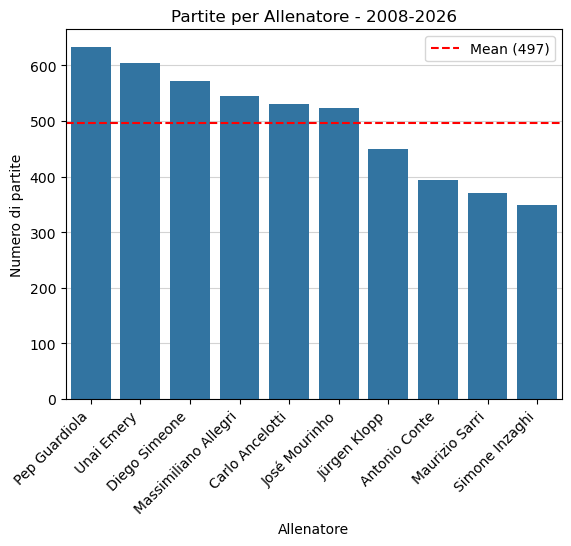

In [6]:
ax = sns.barplot(mm["manager"].value_counts())

plt.xticks(rotation=45, ha="right")

ax.yaxis.grid(True, color="lightgrey", linestyle="-", linewidth=0.8)
ax.set_axisbelow(True)

mean_val = mm["manager"].value_counts().mean()
ax.axhline(mean_val, color="red", linestyle="--", linewidth=1.5, label=f"Mean ({mean_val:.0f})")

ax.legend()

ax.set_xlabel("Allenatore")
ax.set_ylabel("Numero di partite")
ax.set_title("Partite per Allenatore - 2008-2026")



### Partite e Percentuali

A questo punto, per ogni allenatore calcoliamo quante partite sono state vinte, quante per 1-0 e quante sono state vinte con un goal di scarto.

In [7]:
def baseline(df):
    wins  = df[df["result"] == "W"]
    total = len(df)
    tw    = len(wins)
    one_nil    = ((wins["goals_for"] == 1) & (wins["goals_against"] == 0)).sum()
    plus1_all  = (wins["goal_diff"] == 1).sum()
    plus1_excl = ((wins["goal_diff"] == 1) & (wins["goals_against"] > 0)).sum()
    blowout    = (wins["goal_diff"] >= 3).sum()
    return pd.Series({
        "matches"        : total,
        "win_%"          : round(tw / total * 100, 1),
        "1-0_%_wins"     : round(one_nil   / tw * 100, 1) if tw else None,
        "+1_%_wins"      : round(plus1_all  / tw * 100, 1) if tw else None,
        "+1_excl1-0_%"   : round(plus1_excl / tw * 100, 1) if tw else None,
        "blowout_%_wins" : round(blowout    / tw * 100, 1) if tw else None,
        "avg_ga"         : round(df["goals_against"].mean(), 2),
    })

# ref = mm.groupby("manager").apply(baseline).loc[MANAGERS]
# print(ref.sort_values("1-0_%_wins", ascending = False).to_string())

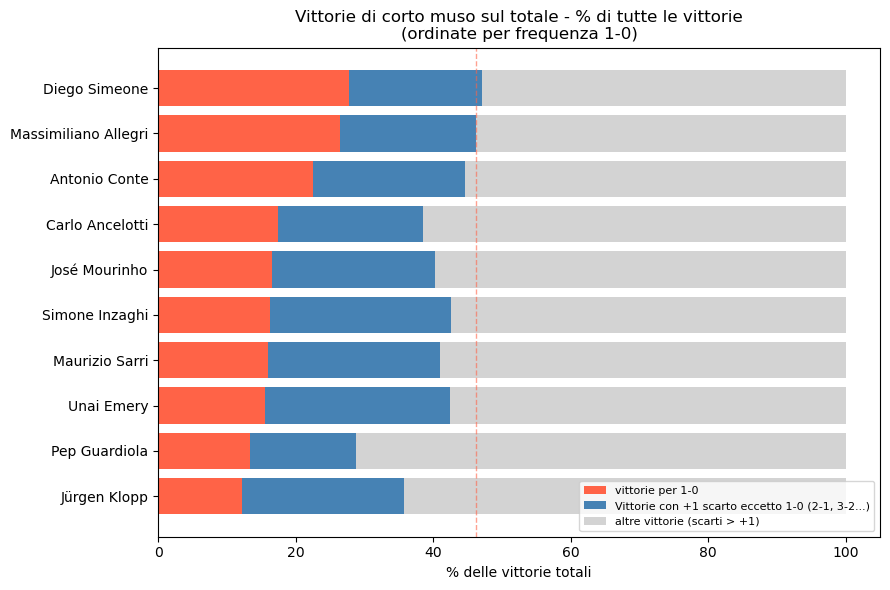

                      matches  win_%  1-0_%_wins  +1_%_wins  +1_excl1-0_%  blowout_%_wins  avg_ga
manager                                                                                          
Diego Simeone           572.0   59.8        27.8       47.1          19.3            22.8    0.83
Massimiliano Allegri    544.0   59.2        26.4       46.3          19.9            22.0    0.89
Antonio Conte           393.0   65.4        22.6       44.7          22.2            24.1    0.87
Carlo Ancelotti         531.0   64.0        17.4       38.5          21.2            35.3    0.92
José Mourinho           523.0   58.9        16.6       40.3          23.7            29.2    0.97
Simone Inzaghi          349.0   59.9        16.3       42.6          26.3            29.2    1.10
Maurizio Sarri          370.0   54.1        16.0       41.0          25.0            24.5    1.06
Unai Emery              605.0   51.9        15.6       42.4          26.8            25.5    1.17
Pep Guardiola       

In [8]:
# stacked horizontal bar: 1-0 wins, +1 excl 1-0, other wins — % of total wins
ref2 = mm.groupby("manager").apply(baseline).loc[MANAGERS].copy()

# sort by 1-0% descending
ref2 = ref2.sort_values("1-0_%_wins", ascending=True)  # ascending=True: top of chart = highest

other = 100 - ref2["+1_%_wins"] - ref2["blowout_%_wins"]
# "other wins" = wins that are not +1 GD and not blowouts
other_pct = 100 - ref2["+1_%_wins"] - ref2["blowout_%_wins"]

fig, ax = plt.subplots(figsize=(9, 6))

bars1 = ax.barh(ref2.index, ref2["1-0_%_wins"],
                color="tomato", label="vittorie per 1-0")
bars2 = ax.barh(ref2.index, ref2["+1_excl1-0_%"],
                left=ref2["1-0_%_wins"],
                color="steelblue", label="Vittorie con +1 scarto eccetto 1-0 (2-1, 3-2...)")
bars3 = ax.barh(ref2.index, 100 - ref2["+1_%_wins"],
                left=ref2["+1_%_wins"],
                color="lightgrey", label="altre vittorie (scarti > +1)")

ax.axvline(ref2.loc["Massimiliano Allegri", "+1_%_wins"],
           color="tomato", linestyle="--", linewidth=1, alpha=0.6)

ax.set_xlabel("% delle vittorie totali")
ax.set_title("Vittorie di corto muso sul totale - % di tutte le vittorie\n(ordinate per frequenza 1-0)")
ax.legend(loc="lower right", fontsize=8)

plt.tight_layout()
plt.show()

ref = mm.groupby("manager").apply(baseline).loc[MANAGERS]
print(ref.sort_values("1-0_%_wins", ascending = False).to_string())

Consideriamo singolarmente tre parametri: le percentuali di vittorie, le vittorie per 1-0, e le vittorie con un solo goal di scarto. 

---

## Il segnale e il rumore

Nei paragrafi precedenti abbiamo contato, per ogni allenatore, le partite vinte per 1-0 e calcolato la percentuale sul totale delle vittorie. Questa percentuale prova a tradurre numericamente uno degli assiomi del corto muso: cercare di vincere, quando si vince, con il minimo sforzo.

In [11]:
ref_10 = ref[['matches', '1-0_%_wins']].sort_values('1-0_%_wins', ascending=False).reset_index()
allegri_10 = ref_10.loc[ref_10['manager'] == 'Massimiliano Allegri', '1-0_%_wins'].values[0]
ref_10['1-0_%_diff_allegri'] = (ref_10['1-0_%_wins'] - allegri_10).round(1)
print(ref_10)

                manager  matches  1-0_%_wins  1-0_%_diff_allegri
0         Diego Simeone    572.0        27.8                 1.4
1  Massimiliano Allegri    544.0        26.4                 0.0
2         Antonio Conte    393.0        22.6                -3.8
3       Carlo Ancelotti    531.0        17.4                -9.0
4         José Mourinho    523.0        16.6                -9.8
5        Simone Inzaghi    349.0        16.3               -10.1
6        Maurizio Sarri    370.0        16.0               -10.4
7            Unai Emery    605.0        15.6               -10.8
8         Pep Guardiola    633.0        13.3               -13.1
9          Jürgen Klopp    450.0        12.2               -14.2


Dalla tabella, sembrerebbe che Allegri abbia una tendenza a vincere per 1-0 superiore alla maggior parte dei suoi colleghi, fatta eccezione per Diego Simeone. Le differenze sono di varia entità: circa quattro punti percentuali rispetto ad Antonio Conte, tredici rispetto a Guardiola, quattordici rispetto a Klopp.

Sono numeri diversi. Ma sono differenze *statisticamente* diverse? La domanda non è oziosa, e per rispondere bisogna capire cosa stiamo davvero misurando quando calcoliamo questa percentuale.

### Una percentuale è una stima, non una verità

Quando diciamo che il 26.4% delle vittorie di Allegri è arrivato per 1-0, stiamo facendo una misura su un campione finito di partite, ossia le 322 vittorie che Allegri ha effettivamente collezionato nei dati che abbiamo. Quella percentuale e' la nostra migliore *stima* della sua tendenza a vincere 1-0, ma non è la tendenza stessa. È il numero che esce dalla nostra misurazione, con tutta la variabilità che una misurazione si porta dietro.

Questa distinzione non e' una sottigliezza filosofica, ma e' esattamente il punto pratico. Se Allegri allenasse altre 322 partite con lo stesso atteggiamento, la percentuale di 1-0 non sarebbe esattamente 26.4%. Sarebbe vicina, ma non identica. Potrebbe essere 25%, potrebbe essere 28%. C'è una "probabilita' vera" sottostante, ossia quella che riflette davvero come Allegri imposta le partite, e c'e' la "percentuale osservata", che è quello che vediamo nei dati. Le due coincidono solo nel limite di un numero infinito di partite, che non abbiamo a disposizione.

Per capire quanto possa essere ampia questa variabilità, l'esempio classico è quello del lancio della moneta.

### L'esempio della moneta

Supponiamo di avere una moneta non truccata: la probabilità "vera" che esca testa e' del 50%. Se vi trovate a una festa con molti invitati laureati in fisica o in matematica, potete dire che questo  e' il valore di massima entropia per una variabile binaria che è la stessa cosa che diremmo intuitivamente: non c'è motivo di preferire un esito all'altro. A proposito di probabilita': se vi trovate a una festa con molti fisici, l'evento e' gia' raro. Se la festa con molti fisici e' anche divertente, probabilmente avete bisogno di una scala logaritmica per misurare quanto sia improbabile.

Usiamo una funzione Python, `np.random.binomial`, che simula il numero di teste ottenute in $N$ lanci. Lanciamo dieci monete, una volta sola:

In [12]:
np.random.seed(42)
np.random.binomial(n=10, p=0.5, size=1)

array([4], dtype=int32)

Il risultato e' `[4]`: su dieci lanci sono uscite quattro teste. Non cinque, come ci si potrebbe aspettare. Nessuno chiamerebbe truccata la moneta per questo. Ripetiamo l'esperimento cinque volte, sempre con dieci lanci ciascuno:

In [13]:
np.random.seed(42)
np.random.binomial(n=10, p=0.5, size=5)

array([4, 8, 6, 5, 3], dtype=int32)

Risultati: 4, 8, 6, 5, 3 teste — ossia $40\%$, $80\%$, $60\%$, $50\%$, $30\%$. La moneta è la stessa, la probabilità "vera" è sempre del $50\%$, ma la percentuale *osservata* in ciascun esperimento oscilla parecchio. Con dieci lanci, la variabilità e' grande.

Il nostro intuito ci dice anche che, aumentando il numero di lanci, le stime dovrebbero stringersi attorno al valore vero. Verifichiamo: cinque esperimenti, ma stavolta con 100 lanci ciascuno.

In [14]:
np.random.seed(42)
np.random.binomial(n=100, p=0.5, size=5)

array([49, 52, 44, 42, 58], dtype=int32)

Risultati: 49, 52, 44, 42, 58 teste, ossia percentuali tra il $42\%$ e il $58\%$. L'oscillazione c'è ancora, nemmeno un $50\%$ spaccato, ma e' molto più contenuta che con dieci lanci. E' la lezione fondamentale: **la variabilità di una percentuale dipende dalla dimensione del campione su cui la misuriamo.** Più dati, meno rumore.

E qui torniamo al calcio.

### Cosa fa un test statistico

Il test di proporzione si pone esattamente questa domanda, ma in una forma rovesciata che vale la pena spiegare. Il test parte da un'ipotesi di partenza, detta *ipotesi nulla*: supponiamo che Allegri e Klopp abbiano in realtà la *stessa* probabilità di vincere 1-0. Chiamiamo questa probabilita' $p$, qualunque essa sia. Anche se puo' sembrare fatto a posta, spesso si usano simboli simili per rappresentare cose diverse: la probabilita' $p$ non ha nulla a che fare con il *p-value* che definiremo poi. Anzi, ammettiamolo: lo facciamo apposta per confondervi. E confonderci. Sotto questa ipotesi, le differenze che osserviamo tra le percentuali misurate dovrebbero essere solo rumore di misurazione, come nell'esperimento delle monete.

A questo punto il test calcola: dato il rumore atteso (che dipende dalle dimensioni dei due campioni, 322 e 271), quanto è probabile osservare una differenza *grande almeno quanto quella che abbiamo visto*, ossia quattordici punti percentuali, se davvero le due probabilità sottostanti fossero uguali?

***Questa probabilità si chiama p-value***. È un numero importante e spesso frainteso. Il p-value **non è** la probabilità che le due percentuali siano uguali. Non è la probabilità che l'ipotesi nulla sia vera. E', più precisamente, la probabilità di osservare una differenza grande come quella che vediamo, o ancora più grande, *assumendo che* le due probabilità sottostanti siano davvero identiche.

Se il p-value è basso, vuol dire: una differenza di questa entità sarebbe molto sorprendente se le due probabilità fossero uguali. Quindi *forse* non lo sono. Se il p-value è alto, vuol dire: una differenza di questa entità è perfettamente compatibile con due probabilità uguali e un po' di rumore e quindi non abbiamo motivo di affermare che siano diverse.

Notare il "non abbiamo motivo di affermare che siano diverse" è molto diverso da "abbiamo dimostrato che sono uguali". I test statistici, in generale, non *dimostrano* niente. Ci dicono quanto sia compatibile quello che vediamo con un'ipotesi di partenza. La conclusione finale, su cosa significa quella compatibilità, sta a noi.

### Un esempio ai due estremi: Allegri vs Klopp

Credo sia difficile trovare due commentatori che trovino l'approccio alle gare di Allegri e Klopp (in rigoroso ordine alfabetico) simile. Questa frase sarebbe piaciuta a statisti quali Romano Prodi, famoso per le sue dichiarazioni dirompenti e provocatorie. Inutile sottolineare le differenze nello stile in cui questi allenatori affrontano le partite e sta al gusto di chi le guarda e commenta decidere quale approccio preferire (spirito di Romano Prodi, esci da questo corpo!!). Ma questo approccio diverso, si riflette poi sui risultati? 

Precisazione importante: Allegri e Klopp hanno allenato in campionati diversi e questo influenza l'*interpretazione* del test statistico. Il test di proporzione non sa cosa sia un campionato. Confronta due numeri e si chiede se la differenza che osserviamo sta dentro al normale rumore statistico. E questo e'. Ma la Serie A e' tradizionalmente un campionato che produce meno goal della Premier League: un allenatore di Serie A vedra' piu' 1-0 semplicemente per il contesto in cui lavora, non per una sua specifica caratteristica filosofica. Quindi anche se il test trovasse una differenza significativa tra Allegri e Klopp, attribuirla all'allenatore richiede un salto interpretativo che il test, per quanto ben fatto, non e' in grado di giustificare da solo. E qui c'e' una distinzione che vale la pena tenere a mente per tutta l'analisi che segue: **il risultato di un test statistico e' una cosa, la sua interpretazione e' un'altra**. Che non significa che si possa fare cherry picking o che il test sia inutile perche' tanto lo si interpreta come si vuole: significa porre dei paletti importanti che indirizzano e vincolano l'interpretazione. Insomma, una volta fatto il test, non si puo' dire tutto e il contrario di tutto.

Andiamo a vedere i numeri che hanno i due allenatori per quanto riguarda numero di vittorie, numero di vittorie per 1-0 e numero di vittorie con un solo goal di scarto.

In [15]:
managers = ["Massimiliano Allegri", "Jürgen Klopp"]

summary = corto_muso_summary(managers, mm)
print(summary.to_string())

                      total_matches  total_wins  one_nil  min_response  corto_muso  win_%  1-0_%  min_resp_%  corto_muso_%
manager                                                                                                                   
Massimiliano Allegri            544         322       85            64         149   59.2   26.4        19.9          46.3
Jürgen Klopp                    450         271       33            64          97   60.2   12.2        23.6          35.8


Come numero di vittorie, il numero e' comparabile, e anche la percentuale di vittorie per partite giocate e' simile, circa il $60\%$. Chiariamo che, in questa tabella, le vittorie di risposta minima (`min_resp`), sono quelle in cui l'avversario ha segnato almeno un goal, e la vittoria e' avvenuta con un goal di scarto. Se ci concentriamo sulle percentuali, abbiamo tre casi: la percentuale di vittorie per 1-0 di Allegri e' superiore a quella di Klopp di circa 14 punti percentuali (sembra riportare i risultati di un'elezione in Basilicata); la percentuale di vittorie con un solo goal di scarto (escludendo gli 1-0) di Klopp e' superiore a quella di Allegri di poco meno di 4 punti; infine la percentuale di vittorie di corto muso (la somma delle due) e' ancora a favore di Allegri di poco meno di 11 punti.

Ci chiediamo: queste differenze, sono statisticamente significative? Riflettono un effetto reale dell'allenatore e del suo approccio, oppure sono semplicemente quello che ci aspettiamo dal caso e dalla normale variabilità delle misure?

Calcoliamo quattro test, ognuno su una proporzione diversa: le percentuali di vittorie complessive (sul totale delle partite); le percentuali di vittorie per 1-0 (sul totale delle vittorie); le percentuali di vittorie con un solo goal di scarto tra le vittorie in cui l'avversario ha segnato almeno una volta (un denominatore piu' piccolo, su cui torniamo tra poco); e le percentuali di vittorie corto muso (1-0 piu' minimo scarto) sul totale delle vittorie.

In [16]:
from statsmodels.stats.proportion import proportion_confint, proportions_ztest

allegri = get_counts("Massimiliano Allegri", mm)
klopp   = get_counts("Jürgen Klopp", mm)

# compute corto muso counts
cm_allegri = allegri["one_nil"] + allegri["min_resp"]
cm_klopp   = klopp["one_nil"]   + klopp["min_resp"]

# proportions
p_win_allegri    = allegri["wins"]   / allegri["matches"]
p_win_klopp      = klopp["wins"]     / klopp["matches"]

p_10_allegri     = allegri["one_nil"] / allegri["wins"]
p_10_klopp       = klopp["one_nil"]   / klopp["wins"]

p_minresp_allegri = allegri["min_resp"] / allegri["opp_scored"]
p_minresp_klopp   = klopp["min_resp"]   / klopp["opp_scored"]

p_cm_allegri     = cm_allegri / allegri["wins"]
p_cm_klopp       = cm_klopp   / klopp["wins"]

# z-tests
z1, pv1 = proportions_ztest([allegri["wins"],    klopp["wins"]],
                             [allegri["matches"], klopp["matches"]])

z2, pv2 = proportions_ztest([allegri["one_nil"], klopp["one_nil"]],
                             [allegri["wins"],    klopp["wins"]])

z3, pv3 = proportions_ztest([allegri["min_resp"],   klopp["min_resp"]],
                             [allegri["opp_scored"], klopp["opp_scored"]])

z4, pv4 = proportions_ztest([cm_allegri,         cm_klopp],
                             [allegri["wins"],    klopp["wins"]])

print("1. Percentuale di vittorie")
print(f"   Allegri: {p_win_allegri*100:.1f}%  |  Klopp: {p_win_klopp*100:.1f}%")
print(f"   Z = {z1:.3f}  |  p = {pv1:.4f}")

print("2. Percentuale di vittorie per 1-0")
print(f"   Allegri: {p_10_allegri*100:.1f}%  |  Klopp: {p_10_klopp*100:.1f}%")
print(f"   Z = {z2:.3f}  |  p = {pv2:.4f}")

print("3. Percentuale di vittorie con margine +1 e avversario a segno (2-1, 3-2...)")
print(f"   Allegri: {p_minresp_allegri*100:.1f}%  |  Klopp: {p_minresp_klopp*100:.1f}%")
print(f"   Z = {z3:.3f}  |  p = {pv3:.4f}")

print("4. Percentuale di vittorie corto muso (1-0 + margine +1 con avversario a segno)")
print(f"   Allegri: {p_cm_allegri*100:.1f}%  |  Klopp: {p_cm_klopp*100:.1f}%")
print(f"   Z = {z4:.3f}  |  p = {pv4:.4f}")


1. Percentuale di vittorie
   Allegri: 59.2%  |  Klopp: 60.2%
   Z = -0.330  |  p = 0.7415
2. Percentuale di vittorie per 1-0
   Allegri: 26.4%  |  Klopp: 12.2%
   Z = 4.321  |  p = 0.0000
3. Percentuale di vittorie con margine +1 e avversario a segno (2-1, 3-2...)
   Allegri: 58.2%  |  Klopp: 48.9%
   Z = 1.445  |  p = 0.1484
4. Percentuale di vittorie corto muso (1-0 + margine +1 con avversario a segno)
   Allegri: 46.3%  |  Klopp: 35.8%
   Z = 2.580  |  p = 0.0099


Cosa ci dicono questi numeri sui risultati ottenuti da Allegri e Klopp *dal punto di vista statistico*:
1. La differenza di un punto tra percentuali di vittorie e' cosi' bassa da essere insignificante;
2. La differenza di 14 punti e' significativa: sotto l'ipotesi che Allegri e Klopp avessero la stessa probabilita' "vera" di vincere 1-0, osservare nei dati una differenza grande almeno quanto questa sarebbe estremamente improbabile. Per questo concludiamo che la differenza e' reale e non spiegabile dal solo rumore.
3. La differenza tra le percentuali di vittorie con un solo goal di scarto (tra le vittorie in cui l'avversario ha segnato) e' invece poco significativa. Un p-value di 0.15 (ben al di sopra della soglia standard di 0.05) ci dice che, anche se Allegri e Klopp avessero la stessa probabilita' sottostante, osservare una differenza come quella misurata sarebbe perfettamente plausibile.
4. La differenza tra le percentuali di vittorie corto muso torna invece ad essere statisticamente significativa. Se le due probabilita' sottostanti fossero davvero uguali, ottenere una differenza di oltre dieci punti sarebbe molto improbabile (p = 0.01). Non estremamente improbabile come per il caso dell'1-0, ma comunque improbabile.

A questo punto, mi piace far notare che probabilmente le cose iniziano a farsi poco intuitive, sebbene scientificamente rigorose. Una differenza percentuale tra due allenatori puo' apparire "grande" a prima vista (alla faccia di chi cerca di spiegare qualcosa con un solo dato) e tuttavia non bastare a superare la soglia statistica, come abbiamo visto per il caso del singolo goal di scarto (9 punti di differenza, $p = 0.15$). Viceversa, una differenza apparentemente simile (i 10 punti del corto muso complessivo) puo' invece risultare significativa, perche' poggia su un campione e una struttura dei dati diversi. Il numero di partite giocate, e la base su cui calcoliamo la proporzione, influenzano in modo sensibile il risultato del test: non e' la dimensione della differenza, da sola, a renderla "reale".

### Nessuno mi puo' giudicare (se non decido quanto vale $\alpha$) 

Quando abbiamo discusso se l'Inter fosse una squadra alla quale venissero comminati meno cartellini gialli rispetto ai falli commessi, [avevo discusso il ruolo della soglia di significanza $\alpha$](https://pacoraggio.github.io/reinventing-the-wheel/the_foul_the_whistle_and_the_doubt/the_foul_the_whistle_and_the_doubt.html#football-and-pregnancy-tests). Quando ho detto che la differenza della percentuali di vittorie con un goal di scarto era "non significativa", ho automaticamente sotteso che il valore della soglia di significanza (o significativita'? Boh...) fosse il classico $5\%$. Senza volermi ripetere, scegliere $\alpha$ e' fondamentale quando si fa un test di ipotesi e il suo valore ci da anche un senso di "confidenza" sulle nostre affermazioni. Se decidessi, ad esempio, che il mio valore di $\alpha$  invece che del $5\%$ fosse dell'$80\%$, allora anche la differenza tra le percentuali di vittorie (Allegri al $59.2%$ e Klopp al $60.2%$) diventerebbe statisticamente significativa. Perche' non lo facciamo in questo caso? Mettere una soglia di $\alpha$ all'$80\%$ significherebbe che variazioni minime rispetto al numero di risultati (mettiamo una vittoria in piu' o in meno), risulterebbero statisticamente significative. E' veramente un problema nel nostro caso? Dipende su cosa vogliamo discutere. In questo caso, stiamo studiando un'attitudine, un modo di allenare che, potenzialmente, si riflette sui risultati. Anche quelli a venire, *se volessi scegliere tra Klopp e Allegri come mio futuro allenatore in base ai risultati*. Se voglio decidere basandomi sulla differenza tra le loro percentuali di vittorie, e questa decisione si basa su pochissime partite, potrei commettere un errore e favorire l'uno o l'altro in base a poche partite rispetto a un vero e proprio trend. Ed e' per questo che teniamo la soglia bassa: per essere sicuri che, quando affermiamo una differenza, lo facciamo solo davanti a prove sufficientemente forti. Una soglia troppo alta, invece, ci farebbe cambiare opinione ogni volta che pochi risultati cambiano.

## Allegri contro tutti - e tutti contro Allegri

Finora abbiamo confrontato Allegri con Klopp per spiegare cosa fa un test statistico. Abbiamo visto che, per due dei tre parametri del corto muso, ossia le vittorie per 1-0 e le vittorie corto muso complessive, la differenza tra i due risultava statisticamente significativa. Per il terzo, le vittorie con +1 di scarto quando l'avversario aveva segnato, la differenza era invece nei limiti della normale variabilità.

Ora andiamo a confrontare Allegri e gli altri allenatori che abbiamo preso in considerazione.

In [31]:
def sig(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return "n.s."


def corto_muso_ztest(base_manager, peers, data):
    def get_counts(manager_name):
        sub = data[data["manager"] == manager_name]
        w   = sub[sub["result"] == "W"].copy()
        w["is_one_nil"]      = (w["goals_for"] == 1) & (w["goals_against"] == 0)
        w["is_min_response"] = (w["goals_against"] > 0) & (w["goal_diff"] == 1)
        w_opp = w[w["goals_against"] > 0]
        return {
            "matches"    : len(sub),
            "wins"       : len(w),
            "one_nil"    : int(w["is_one_nil"].sum()),
            "min_resp"   : int(w["is_min_response"].sum()),
            "opp_scored" : len(w_opp),
            "corto_muso" : int(w["is_one_nil"].sum()) + int(w["is_min_response"].sum()),
        }

    base = get_counts(base_manager)

    rows = []
    for peer in peers:
        p = get_counts(peer)

        _, pv1 = proportions_ztest(
            [base["one_nil"], p["one_nil"]],
            [base["wins"],    p["wins"]]
        )
        _, pv2 = proportions_ztest(
            [base["min_resp"],   p["min_resp"]],
            [base["opp_scored"], p["opp_scored"]]
        )
        _, pv3 = proportions_ztest(
            [base["corto_muso"], p["corto_muso"]],
            [base["wins"],       p["wins"]]
        )

        rows.append({
            "peer"           : peer,
            "peer_n"         : p["matches"],
            "p_one_nil"      : round(pv1, 4),
            "sig_one_nil"    : sig(pv1),
            "p_min_resp"     : round(pv2, 4),
            "sig_min_resp"   : sig(pv2),
            "p_corto_muso"   : round(pv3, 4),
            "sig_corto_muso" : sig(pv3),
        })

    return pd.DataFrame(rows)


In [32]:
result = corto_muso_ztest("Massimiliano Allegri", PEERS, mm)
print(result.sort_values("p_corto_muso").to_string(index=False))


           peer  peer_n  p_one_nil sig_one_nil  p_min_resp sig_min_resp  p_corto_muso sig_corto_muso
  Pep Guardiola     633     0.0000         ***      0.0003          ***        0.0000            ***
   Jürgen Klopp     450     0.0000         ***      0.1484         n.s.        0.0099             **
Carlo Ancelotti     531     0.0048          **      0.2155         n.s.        0.0438              *
  José Mourinho     523     0.0027          **      0.2355         n.s.        0.1279           n.s.
 Maurizio Sarri     370     0.0056          **      0.5842         n.s.        0.2383           n.s.
     Unai Emery     605     0.0008         ***      0.5573         n.s.        0.3202           n.s.
 Simone Inzaghi     349     0.0062          **      0.7018         n.s.        0.4036           n.s.
  Antonio Conte     393     0.2884        n.s.      0.6187         n.s.        0.7141           n.s.
  Diego Simeone     572     0.6892        n.s.      0.7874         n.s.        0.8358      

La tabella ci mostra differenze significative essenzialmente per le vittorie per 1-0: effettivamente effettivamente Allegri mostrebbe una tendeza ad avere risultati di vittorei per 1-0 in percentuale, diversa (maggiore in questo caso) alla maggior parte dei suoi colleghi, diversa (maggiore in questo caso) alla maggior parte dei suoi colleghi, eccezion fatta per Conte e Simeone (Simeone avrebbe addirittura una percentuale maggiore di quella di Allegri ma la differenza e' statisticamente impercettibile). Se pero' consideriamo le vittorie per "corto muso", ossia quelle con un +1 come differenza reti includendo gli 1-0, tutti gli allenatori non mostrano differenze statisticamente significative eccezion fatta per Guardiola, Klopp e Ancelotti, quest'ultimo al limite. Cerchiamo di ricordarci sempre la nozione di $\alpha$, giusto per capirci quando diciamo che le differenze sono sono effettivamente significative dal punto di vista statistico.

Vediamo se un grafico ci aiuta nel farci intuire cosa stiamo dicendo.

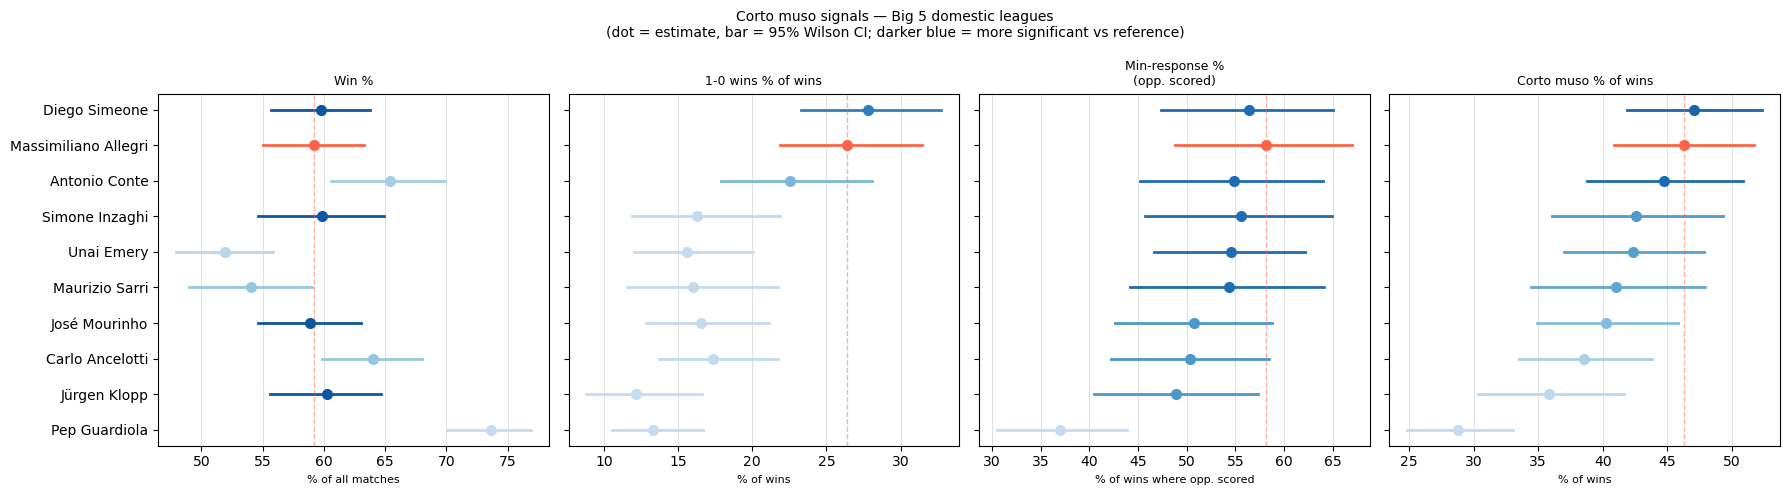

In [46]:
plot_corto_muso_signals(mm, MANAGERS, order = 3)

Andiamo da sinistra a destra (ma solo in questo caso) e cerchiamo di spiegare i risultati ottenuti finora. Gli allenatori sono ordinati dall'alto verso il basso rispetto ai risultati di corto muso, ossia alla percentuale di vittorie con un goal di scarto. Questi grafici indicano le percentuali calcolate e ci aggiungono le barre di errore. Le barre di errore servono a visualizzare la variazione rispetto alla stima della percentuale che e' stata misurata dai dati (ossia il valore calcolato dai dati). Per quello che ho spiegato in precedenza, possiamo dire che dal punto di vista statistico, siamo abbastanza confidenti che il "valore vero" di ogni parametro rientri nell barra di errore. Una precisazione: se due barre non si sovrappongono affatto, la differenza e' certamente significativa. Se si sovrappongono, potrebbe comunque esserlo. L'occhio nudo qui inganna leggermente, ed e' una delle ragioni per cui un test formale aiuta.

1. La prima colonna indica la percentuale di vittorie sulle partite giocate. Il grafico mostra che stiamo confrontando allenatori che, bene o male, hanno una percentuale di vittorie simile. Conte, Ancelotti e Guardiola hanno una percentuale di vittorie superiore (piu' pronunciata quella di Guardiola); Emery e Sarri minore (Sarri siamo al limite);
2. La seconda colonna prende in considerazione la percentuale di vittore per 1-0. Il grafico mostra un gruppetto di tre allenatori che hanno percentuali diverse dagli altri (superiore). Continuo a insistere sulle barre di errore: sono quelle che contano veramente, perche' ci dicono anche cosa potremmo vedere in futuro se quella calcolata e' la frequenza reale (il segnale). E' fuorviante vedere solo i numeri senza considerare l'errore, perche' ci fa credere in qualcosa che, invece, puo' variare anche nel giro di poche partite.
3. La terza colonna si riferisce alle vittorie con un goal di scarto quando l'avversario ha segnato almeno un goal. E qui il grafico mostra alcune cose interessanti. Tutti gli allenatori con una percentuale di vittorie 1-0 inferiore al terzetto di testa sembrano recuperare terreno su questa colonna: vincere con un solo goal di scarto quando l'avversario ha segnato e' un comportamento abbastanza diffuso, che non differenzia molto un allenatore dall'altro. Con due eccezioni: Guardiola, e in misura piu' lieve Klopp (occhio alle barre).
4. Ultima ma non ultima, la quarta colonna e' quella che rappresenta le vittorie di corto muso: non importa dilagare, l'importante e' vincere con un goal di scarto. E se non ci facciamo ingannare dai numeri e vediamo le barre di errore, praticamente solo Mourinho, Ancelotti, Klopp e Guardiola sfuggono da questo tipo di vittoria.

Questa e' l'interpretazione dei test statistici con i dati che abbiamo considerato, ossia vittore e tipo di vittorie. Avendo cosi' pochi parametri, e' difficile, ma non impossibile, trovare differenze che potrebbero essere nascoste dalle caratteristiche intrinseche del gioco del calcio: un gioco dove il punteggio e' basso (rispetto ad altri quali hockey, basket, cricket, pallavolo, pallanuoto) e una vittoria in campionato (ancora, sottoliniamo che stiamo considerando partite di campionato) vale uguale se si vince con un goal di scarto o di otto.

### Penn, Teller, e l'istinto che ci frega - o come le correzioni ci aiutano a non sbagliare.

C'e' un filo sottile che lega gli scienziati e gli illusionisti. Almeno quelli bravi. Sono ad esempio convinto che [James Randi](https://en.wikipedia.org/wiki/James_Randi) sia stato un grandissimo fisico teorico, e che la sua attitudine ad affrontare la vita, sia stata molto piu' scientifica di quella di alcuni premi Nobel (a questo punto dovrebbero fischiare le orecchie a persone come [Luc Montagnier](https://en.wikipedia.org/wiki/Luc_Montagnier) o [Kary Mullis](http://en.wikipedia.org/wiki/Kary_Mullis) se non fosse che a quest'ora le loro orecchie si sono bellamente decomposte). James Randi era amico di Richard Feynman, per dire. 

C'e' un [video di Penn e Teller](https://www.youtube.com/watch?v=8osRaFTtgHo) in cui i due eseguono un vecchio gioco di prestigio con dei bicchieri e delle palline. La particolarita' e' che lo fanno con bicchieri trasparenti, ossia mostrando in chiaro come avviene il trucco. Le palline cambiano posto davanti agli occhi del pubblico, sotto telecamera, e nonostante questo lo spettatore continua a non vederlo. L'istinto, abituato a un certo tipo di gesto e a una certa direzione di attenzione, non riesce a registrare quello che pure e' li' in chiaro. Vediamo il trucco ed e' come se non lo vedessimo.

Qualcosa di simile sta succedendo nella nostra analisi finora. Ho scritto una sezione che ho chiamato "Allegri contro tutti - e tutti contro Allegri" e l'ho strutturata seguendo l'istinto con cui chiunque, guardando una tabella, andrebbe a confrontare il proprio allenatore preferito con tutti gli altri uno per volta. Ho preso ogni p-value, l'ho letto, ho tratto le mie conclusioni, e tutto sembrava in ordine. Solo che, esattamente come davanti ai bicchieri di Penn e Teller, c'era qualcosa che stava avvenendo sotto i nostri occhi e che il nostro istinto non era attrezzato a vedere. 

Ricapitoliamo cosa abbiamo fatto. Per ogni allenatore della lista, ossia Klopp, Guardiola, Mourinho, Conte, Ancelotti, e cosi' via fino ad arrivare a undici, abbiamo confrontato la sua percentuale con quella di Allegri. Tre percentuali per ogni confronto (1-0, vittorie con un goal di scarto a porta non inviolata, corto muso totale) per undici allenatori, fa trentatre' test in totale. E qui c'e' il bicchiere trasparente che non avevamo notato.

## Appendice: Goalmaxxxing

In [21]:
goal_stats = (
    mm.groupby("manager")
    .apply(lambda df: pd.Series({
        "matches"   : len(df),
        "GF_total"  : df["goals_for"].sum(),
        "GA_total"  : df["goals_against"].sum(),
        "TG_total"  : (df["goals_for"] + df["goals_against"]).sum(),
        "GF_mean"   : df["goals_for"].mean().round(2),
        "GA_mean"   : df["goals_against"].mean().round(2),
        "TG_mean"   : (df["goals_for"] + df["goals_against"]).mean().round(2),
        "GF_median" : df["goals_for"].median(),
        "GA_median" : df["goals_against"].median(),
        "TG_median" : (df["goals_for"] + df["goals_against"]).median(),
        "GF_std"    : df["goals_for"].std().round(2),
        "GA_std"    : df["goals_against"].std().round(2),
        "TG_std"    : (df["goals_for"] + df["goals_against"]).std().round(2),
    }))
    .loc[MANAGERS]
)

print(goal_stats.sort_values("TG_mean", ascending=False).to_string())


                      matches  GF_total  GA_total  TG_total  GF_mean  GA_mean  TG_mean  GF_median  GA_median  TG_median  GF_std  GA_std  TG_std
manager                                                                                                                                        
Pep Guardiola           633.0    1566.0     495.0    2061.0     2.47     0.78     3.26        2.0        1.0        3.0    1.61    0.92    1.76
Jürgen Klopp            450.0     950.0     463.0    1413.0     2.11     1.03     3.14        2.0        1.0        3.0    1.50    1.05    1.77
Simone Inzaghi          349.0     695.0     384.0    1079.0     1.99     1.10     3.09        2.0        1.0        3.0    1.43    1.05    1.71
Carlo Ancelotti         531.0    1125.0     487.0    1612.0     2.12     0.92     3.04        2.0        1.0        3.0    1.56    1.01    1.81
Unai Emery              605.0    1065.0     709.0    1774.0     1.76     1.17     2.93        2.0        1.0        3.0    1.35    1.16 

In [25]:
2/32

0.0625